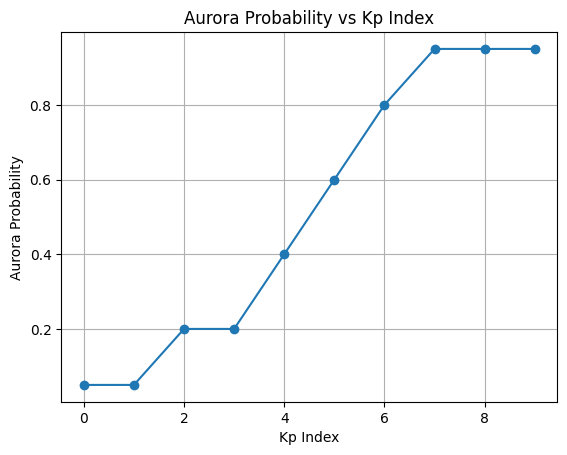

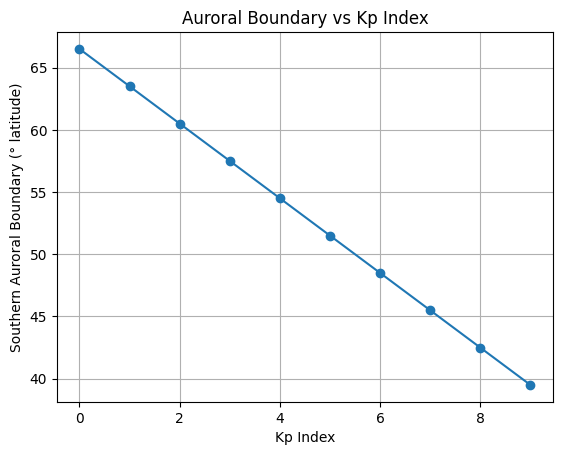

---------------------------

Forecast Results
---------------------------
Kp index: 6.0
Aurora probability: 80%
Southern visibility boundary: ~48.5° latitude
Status: Strong aurora likely! Low-latitude sightings possible.
---------------------------



In [3]:
# Auroa Predictor 1.0

# this code creates a simple 1 to 10 Kp index to aurora probability and latitude boundary predictor, as kp index increses, the probability of seeing auroras increases and the latitude boundary decreases 
# this code does not take in any exteranl data sources, or API calls, it is a basic predictor based on static values

import matplotlib.pyplot as plt

def aurora_probability(kp):
    if kp < 2:
        return 0.05
    elif kp < 4:
        return 0.20
    elif kp < 5:
        return 0.40
    elif kp < 6:
        return 0.60
    elif kp < 7:
        return 0.80
    else:
        return 0.95

def aurora_latitude_boundary(kp):
    return 66.5 - (kp * 3)

# Loop through all possible Kp values
kp_values = list(range(10))
probabilities = []
latitudes = []

for kp in kp_values:
    probabilities.append(aurora_probability(kp))
    latitudes.append(aurora_latitude_boundary(kp))

# Plot 1: Aurora probability vs Kp
plt.figure()
plt.plot(kp_values, probabilities, marker='o')
plt.xlabel("Kp Index")
plt.ylabel("Aurora Probability")
plt.title("Aurora Probability vs Kp Index")
plt.grid(True)
plt.show()

# Plot 2: Southern auroral boundary vs Kp
plt.figure()
plt.plot(kp_values, latitudes, marker='o')
plt.xlabel("Kp Index")
plt.ylabel("Southern Auroral Boundary (° latitude)")
plt.title("Auroral Boundary vs Kp Index")
plt.grid(True)
plt.show()
 


def aurora_probability(kp):
    if kp < 2:
        return 0.05
    elif kp < 4:
        return 0.20
    elif kp < 5:
        return 0.40
    elif kp < 6:
        return 0.60
    elif kp < 7:
        return 0.80
    else:
        return 0.95


def aurora_latitude_boundary(kp):
    return round(66.5 - (kp * 3), 1)

print("---------------------------")

kp_input = input("Enter Kp index (0–9): ")

try:
    kp = float(kp_input)
except ValueError:
    print(" Invalid input. Please enter a number between 0 and 9.")
    exit()

if kp < 0 or kp > 9:
    print(" Kp must be between 0 and 9.")
    exit()

prob = aurora_probability(kp)
lat = aurora_latitude_boundary(kp)

print("\nForecast Results")
print("---------------------------")
print(f"Kp index: {kp}")
print(f"Aurora probability: {int(prob * 100)}%")
print(f"Southern visibility boundary: ~{lat}° latitude")

if prob < 0.2:
    print("Status: Quiet conditions.")
elif prob < 0.5:
    print("Status: Minor aurora possible at high latitudes.")
elif prob < 0.8:
    print("Status: Good aurora potential.")
else:
    print("Status: Strong aurora likely! Low-latitude sightings possible.")

print("---------------------------\n")



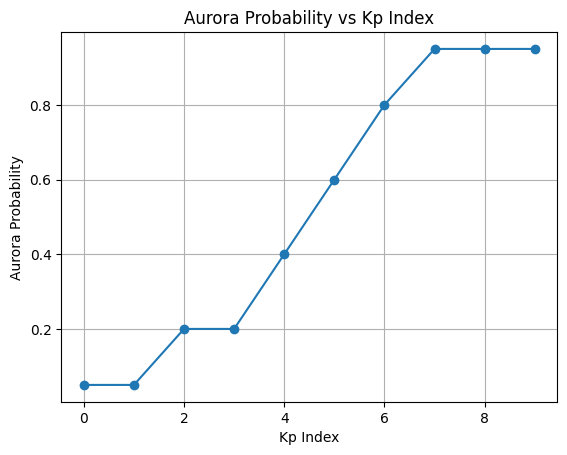

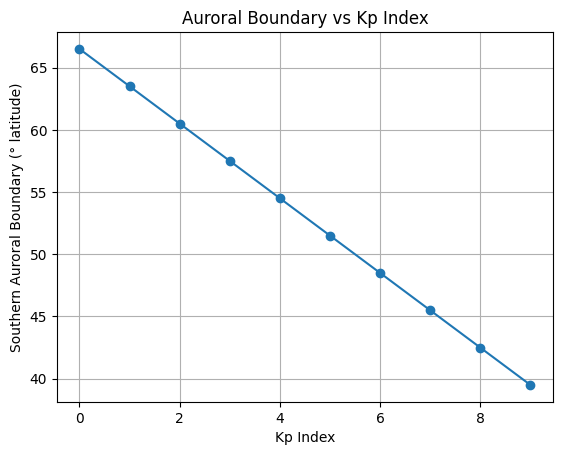

In [2]:

#v 1.2  Basic Aurora Predictor with graph data looped 

# Aurora Baseline: Loop over all Kp values and plot results

import matplotlib.pyplot as plt

def aurora_probability(kp):
    if kp < 2:
        return 0.05
    elif kp < 4:
        return 0.20
    elif kp < 5:
        return 0.40
    elif kp < 6:
        return 0.60
    elif kp < 7:
        return 0.80
    else:
        return 0.95

def aurora_latitude_boundary(kp):
    return 66.5 - (kp * 3)

# Loop through all possible Kp values
kp_values = list(range(10))
probabilities = []
latitudes = []

for kp in kp_values:
    probabilities.append(aurora_probability(kp))
    latitudes.append(aurora_latitude_boundary(kp))

# Plot 1: Aurora probability vs Kp
plt.figure()
plt.plot(kp_values, probabilities, marker='o')
plt.xlabel("Kp Index")
plt.ylabel("Aurora Probability")
plt.title("Aurora Probability vs Kp Index")
plt.grid(True)
plt.show()

# Plot 2: Southern auroral boundary vs Kp
plt.figure()
plt.plot(kp_values, latitudes, marker='o')
plt.xlabel("Kp Index")
plt.ylabel("Southern Auroral Boundary (° latitude)")
plt.title("Auroral Boundary vs Kp Index")
plt.grid(True)
plt.show()


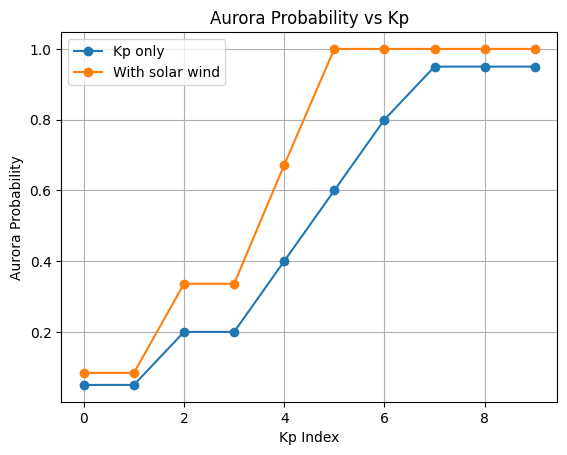

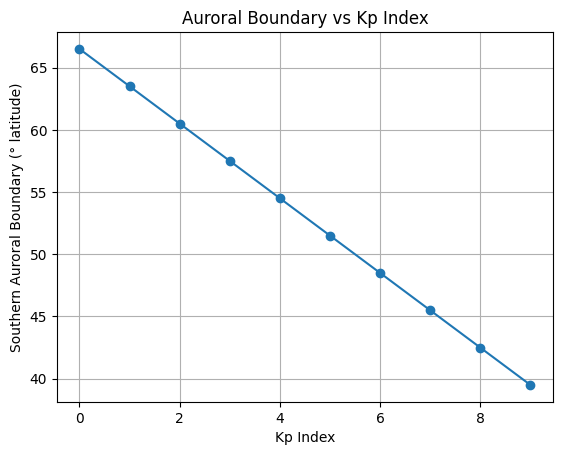

In [5]:
# v 1.3  adding solar wind effects to aurora predictor


import matplotlib.pyplot as plt

# --- Base aurora model (unchanged) ---

def aurora_probability(kp):
    if kp < 2:
        return 0.05
    elif kp < 4:
        return 0.20
    elif kp < 5:
        return 0.40
    elif kp < 6:
        return 0.60
    elif kp < 7:
        return 0.80
    else:
        return 0.95


def aurora_latitude_boundary(kp):
    return 66.5 - (kp * 3)


# --- New physics: solar wind effects ---

def solar_wind_boost(speed, bz):
    """
    speed: km/s (typical 300–800)
    bz: IMF Bz in nT (negative = southward)
    """

    # Speed contribution
    if speed < 400:
        speed_factor = 0.9
    elif speed < 600:
        speed_factor = 1.0
    else:
        speed_factor = 1.2

    # Bz contribution (this matters a LOT)
    if bz > 0:
        bz_factor = 0.7
    elif bz > -5:
        bz_factor = 1.0
    else:
        bz_factor = 1.4

    return speed_factor * bz_factor


# --- Simulated solar wind conditions ---
# (You can change these easily)

solar_wind_speed = 650   # km/s
imf_bz = -8              # nT (southward = good for aurora)

# --- Loop through all Kp values ---

kp_values = list(range(10))
base_probs = []
final_probs = []
latitudes = []

boost = solar_wind_boost(solar_wind_speed, imf_bz)

for kp in kp_values:
    base = aurora_probability(kp)
    final = min(base * boost, 1.0)  # cap at 100%

    base_probs.append(base)
    final_probs.append(final)
    latitudes.append(aurora_latitude_boundary(kp))

# --- Plot 1: Probability comparison ---

plt.figure()
plt.plot(kp_values, base_probs, marker='o', label="Kp only")
plt.plot(kp_values, final_probs, marker='o', label="With solar wind")
plt.xlabel("Kp Index")
plt.ylabel("Aurora Probability")
plt.title("Aurora Probability vs Kp")
plt.legend()
plt.grid(True)
plt.show()

# --- Plot 2: Auroral boundary ---

plt.figure()
plt.plot(kp_values, latitudes, marker='o')
plt.xlabel("Kp Index")
plt.ylabel("Southern Auroral Boundary (° latitude)")
plt.title("Auroral Boundary vs Kp Index")
plt.grid(True)
plt.show()





Aurora Forecast
Location latitude: 52.0°
Local time: 23:00
Solar wind speed: 650 km/s
IMF Bz: -8 nT

Kp 0:  10%  → Not visible
Kp 1:  10%  → Not visible
Kp 2:  43%  → Not visible
Kp 3:  43%  → Not visible
Kp 4:  87%  → Not visible
Kp 5: 100%  → VISIBLE
Kp 6: 100%  → VISIBLE
Kp 7: 100%  → VISIBLE
Kp 8: 100%  → VISIBLE
Kp 9: 100%  → VISIBLE


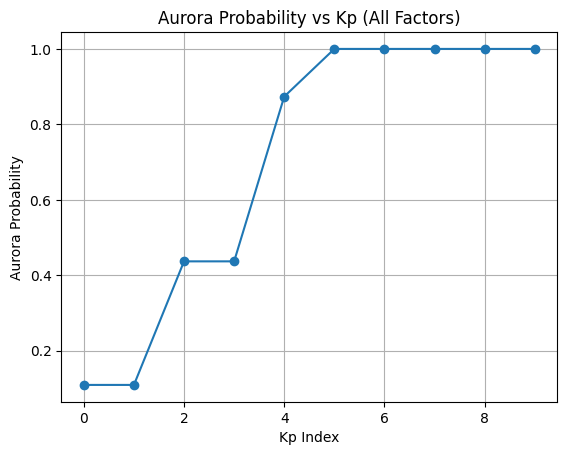

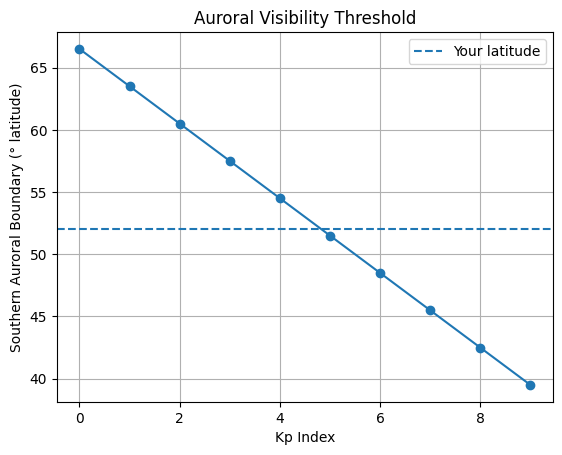

In [ ]:
import matplotlib.pyplot as plt

def aurora_probability(kp):
    if kp < 2:
        return 0.05
    elif kp < 4:
        return 0.20
    elif kp < 5:
        return 0.40
    elif kp < 6:
        return 0.60
    elif kp < 7:
        return 0.80
    else:
        return 0.95


def aurora_latitude_boundary(kp):
    return 66.5 - (kp * 3)


def solar_wind_boost(speed, bz):
    # Speed factor
    if speed < 400:
        speed_factor = 0.9
    elif speed < 600:
        speed_factor = 1.0
    else:
        speed_factor = 1.2

    # IMF Bz factor (dominant)
    if bz > 0:
        bz_factor = 0.7
    elif bz > -5:
        bz_factor = 1.0
    else:
        bz_factor = 1.4

    return speed_factor * bz_factor

def local_time_factor(hour):
    """
    hour: 0–23 local time
    Midnight sector (~22–02) is strongest
    """
    if 22 <= hour or hour <= 2:
        return 1.3
    elif 18 <= hour < 22 or 2 < hour <= 6:
        return 1.1
    else:
        return 0.9


def storm_memory_factor(previous_kp, current_kp):
    """
    Simple persistence model:
    aurora activity lingers after peak
    """
    if previous_kp >= 6 and current_kp < previous_kp:
        return 1.15
    else:
        return 1.0



user_latitude = 52.0        # degrees
local_time = 23             # hour (0–23)
solar_wind_speed = 650      # km/s
imf_bz = -8                 # nT (negative = southward)

kp_values = list(range(10))
final_probs = []
visibility = []

previous_kp = 0

for kp in kp_values:
    base = aurora_probability(kp)

    boost_sw = solar_wind_boost(solar_wind_speed, imf_bz)
    boost_time = local_time_factor(local_time)
    boost_memory = storm_memory_factor(previous_kp, kp)

    final_prob = base * boost_sw * boost_time * boost_memory
    final_prob = min(final_prob, 1.0)

    boundary_lat = aurora_latitude_boundary(kp)
    visible = user_latitude >= boundary_lat

    final_probs.append(final_prob)
    visibility.append(visible)

    previous_kp = kp


print("\nAurora Forecast")
print("===========================================")
print(f"Location latitude: {user_latitude}°")
print(f"Local time: {local_time}:00")
print(f"Solar wind speed: {solar_wind_speed} km/s")
print(f"IMF Bz: {imf_bz} nT\n")

for kp, prob, vis in zip(kp_values, final_probs, visibility):
    status = "VISIBLE" if vis else "Not visible"
    print(f"Kp {kp}: {int(prob*100):3d}%  → {status}")



plt.figure()
plt.plot(kp_values, final_probs, marker='o')
plt.xlabel("Kp Index")
plt.ylabel("Aurora Probability")
plt.title("Aurora Probability vs Kp (All Factors)")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(kp_values,
         [aurora_latitude_boundary(kp) for kp in kp_values],
         marker='o')
plt.axhline(user_latitude, linestyle='--', label="Your latitude")
plt.xlabel("Kp Index")
plt.ylabel("Southern Auroral Boundary (° latitude)")
plt.title("Auroral Visibility Threshold")
plt.legend()
plt.grid(True)
plt.show()


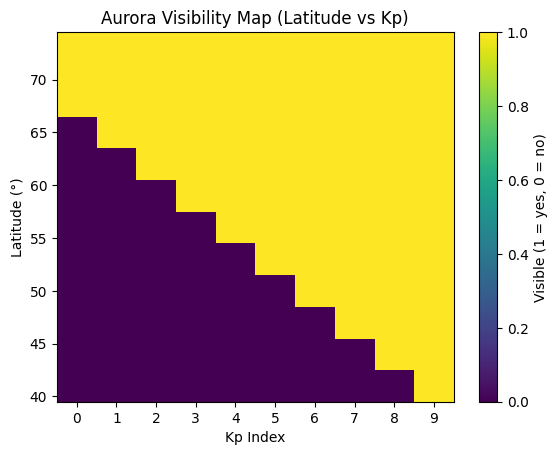

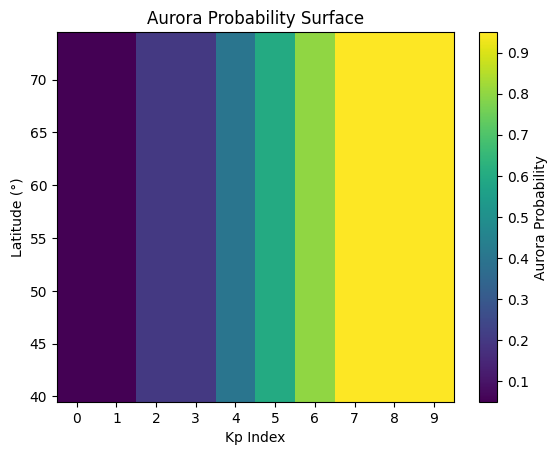

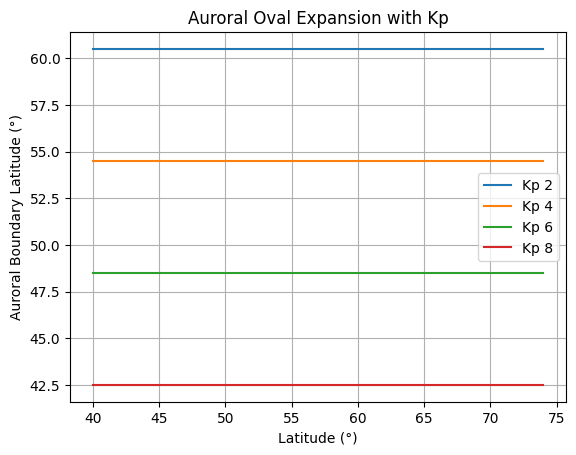

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def aurora_probability(kp):
    if kp < 2:
        return 0.05
    elif kp < 4:
        return 0.20
    elif kp < 5:
        return 0.40
    elif kp < 6:
        return 0.60
    elif kp < 7:
        return 0.80
    else:
        return 0.95


def aurora_latitude_boundary(kp):
    # Southern boundary of auroral oval
    return 66.5 - (kp * 3)


kp_values = np.arange(0, 10, 1)           # Kp 0–9
latitudes = np.arange(40, 75, 1)          # 40°–74° latitude

visibility_grid = np.zeros((len(latitudes), len(kp_values)))
probability_grid = np.zeros_like(visibility_grid)


for i, lat in enumerate(latitudes):
    for j, kp in enumerate(kp_values):
        boundary = aurora_latitude_boundary(kp)
        prob = aurora_probability(kp)

        probability_grid[i, j] = prob
        visibility_grid[i, j] = 1 if lat >= boundary else 0


plt.figure()
plt.imshow(
    visibility_grid,
    aspect="auto",
    origin="lower"
)

plt.colorbar(label="Visible (1 = yes, 0 = no)")
plt.xticks(range(len(kp_values)), kp_values)
plt.yticks(range(0, len(latitudes), 5), latitudes[::5])

plt.xlabel("Kp Index")
plt.ylabel("Latitude (°)")
plt.title("Aurora Visibility Map (Latitude vs Kp)")

plt.show()


plt.figure()
plt.imshow(
    probability_grid,
    aspect="auto",
    origin="lower"
)

plt.colorbar(label="Aurora Probability")
plt.xticks(range(len(kp_values)), kp_values)
plt.yticks(range(0, len(latitudes), 5), latitudes[::5])

plt.xlabel("Kp Index")
plt.ylabel("Latitude (°)")
plt.title("Aurora Probability Surface")

plt.show()


plt.figure()

for kp in [2, 4, 6, 8]:
    boundary = aurora_latitude_boundary(kp)
    plt.plot(latitudes, [boundary] * len(latitudes), label=f"Kp {kp}")

plt.xlabel("Latitude (°)")
plt.ylabel("Auroral Boundary Latitude (°)")
plt.title("Auroral Oval Expansion with Kp")
plt.legend()
plt.grid(True)

plt.show()
